## Exploratory Data Analysis (EDA) for Bank Datasets

In this notebook, we will conduct a preliminary analysis of the bank datasets to uncover patterns, detect anomalies, and test hypotheses.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, RFE
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")

## Loading the Data

We will load the four datasets to understand their structure and contents.

In [2]:
# Load the datasets
bank_data = pd.read_csv('bank.csv', delimiter=';')
bank_additional = pd.read_csv('bank-additional.csv', delimiter=';')
bank_additional_full = pd.read_csv('bank-additional-full.csv', delimiter=';')
bank_full = pd.read_csv('bank-full.csv', delimiter=';')

# Display the first few rows of each dataset
print("First few rows of the Bank dataset:")
display(bank_data.head())

print("First few rows of the Bank Additional dataset:")
display(bank_additional.head())

print("First few rows of the Bank Additional Full dataset:")
display(bank_additional_full.head())

print("First few rows of the Bank Full dataset:")
display(bank_full.head())

First few rows of the Bank dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


First few rows of the Bank Additional dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


First few rows of the Bank Additional Full dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


First few rows of the Bank Full dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Combine the datasets
bank = pd.concat([bank_data, bank_additional, bank_additional_full, bank_full], ignore_index=True)

# Display the shape and the first few rows of the combined dataset
print("Shape of combined dataset:", bank.shape)
display(bank.head())

Shape of combined dataset: (95039, 23)


,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,...,339,4,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,...,330,1,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Display column names
print("Column names in the combined dataset:")
print(bank.columns.tolist())

Column names in the combined dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'day_of_week', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [5]:
# Columns to drop
columns_to_drop = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'day']

bank = bank.drop(columns=columns_to_drop)

In [6]:
# Display column names
print("Column names in the combined dataset:")
print(bank.columns.tolist())

Column names in the combined dataset:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'day_of_week']


In [7]:
# Display dataset information
print("\nDataset Information:")
bank.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95039 entries, 0 to 95038
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          95039 non-null  int64  
 1   job          95039 non-null  object 
 2   marital      95039 non-null  object 
 3   education    95039 non-null  object 
 4   default      95039 non-null  object 
 5   balance      49732 non-null  float64
 6   housing      95039 non-null  object 
 7   loan         95039 non-null  object 
 8   contact      95039 non-null  object 
 9   month        95039 non-null  object 
 10  duration     95039 non-null  int64  
 11  campaign     95039 non-null  int64  
 12  pdays        95039 non-null  int64  
 13  previous     95039 non-null  int64  
 14  poutcome     95039 non-null  object 
 15  y            95039 non-null  object 
 16  day_of_week  45307 non-null  object 
dtypes: float64(1), int64(5), object(11)
memory usage: 12.3+ MB


## Handling Missing values

In [8]:
# Display information about missing values
print("\nMissing Values in the Dataset:")
missing_values = bank.isnull().sum()
print(missing_values[missing_values > 0])  # This will print columns with missing values and their count


Missing Values in the Dataset:
balance        45307
day_of_week    49732
dtype: int64


In [9]:
# Columns to drop
columns_to_drop = ['day_of_week', 'balance']

bank = bank.drop(columns=columns_to_drop)

In [10]:
# Display information about missing values
print("\nMissing Values in the Dataset:")
missing_values = bank.isnull().sum()
print(missing_values[missing_values > 0])  # This will print columns with missing values and their count


Missing Values in the Dataset:
Series([], dtype: int64)


In [11]:
# Display dataset information
print("\nDataset Information:")
bank.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95039 entries, 0 to 95038
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        95039 non-null  int64 
 1   job        95039 non-null  object
 2   marital    95039 non-null  object
 3   education  95039 non-null  object
 4   default    95039 non-null  object
 5   housing    95039 non-null  object
 6   loan       95039 non-null  object
 7   contact    95039 non-null  object
 8   month      95039 non-null  object
 9   duration   95039 non-null  int64 
 10  campaign   95039 non-null  int64 
 11  pdays      95039 non-null  int64 
 12  previous   95039 non-null  int64 
 13  poutcome   95039 non-null  object
 14  y          95039 non-null  object
dtypes: int64(5), object(10)
memory usage: 10.9+ MB


## Encoding Categorical Variables

In [12]:
#Encode Categorical Variables

categorical_cols = bank.select_dtypes(include=['object']).columns.drop('y', errors='ignore')

encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = encoder.fit_transform(bank[categorical_cols])
categorical_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out())
bank = bank.drop(columns=categorical_cols)
bank = pd.concat([bank, categorical_df], axis=1)

Handling Imbalance in the column 'y'.

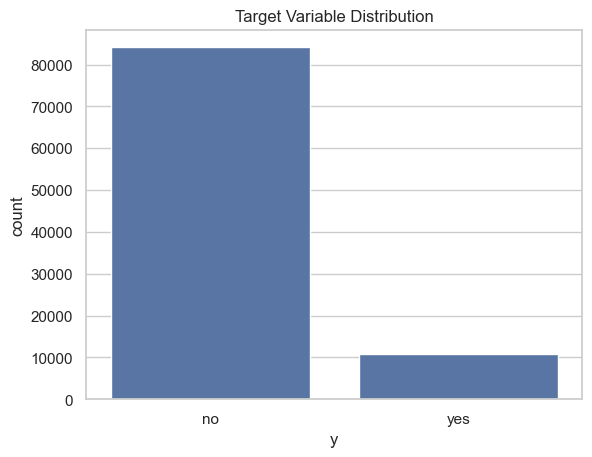

In [13]:
#Checking Class Balance
sns.countplot(x='y', data=bank)
plt.title("Target Variable Distribution")
plt.show()

In [14]:
# Convert target variable to binary
bank['y'] = bank['y'].map({'no': 0, 'yes': 1})


In [15]:
# Identify numerical columns
numerical_cols = bank.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('y')  # Exclude target variable

## Handling Outliers

In [16]:

# 🔹 **Step 1: Remove Outliers using Isolation Forest**
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(bank[numerical_cols])
bank_clean = bank[outliers == 1]  # Keep only inliers
print("✅ Outlier Detection and Removal Completed:", bank_clean.shape)

✅ Outlier Detection and Removal Completed: (90288, 53)


In [17]:
# 🔹 **Step 2: Define Features and Target AFTER Outlier Removal**
X = bank_clean.drop(columns=['y'])
y = bank_clean['y']

## Class Balancing using SMOTE

In [18]:
 #**Step 3: Apply SMOTE for Class Balancing**
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("✅ SMOTE Applied: Balanced dataset shape:", X_resampled.shape)

✅ SMOTE Applied: Balanced dataset shape: (161200, 52)


## Scaling

In [19]:
# 🔹 **Step 4: Apply Standard Scaling**
scaler = StandardScaler()
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])
print("\n✅ Scaling Completed Successfully!")


✅ Scaling Completed Successfully!


## Correlations

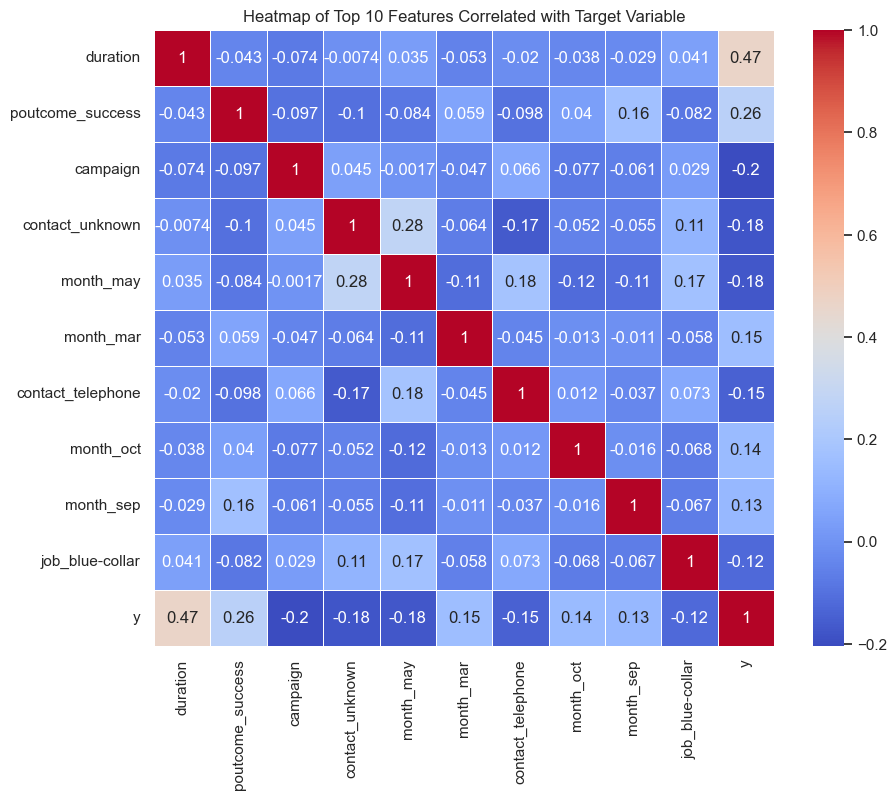

In [20]:
# Create DataFrame with resampled data
resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df['y'] = y_resampled  # Correctly assign the balanced target variable

# Compute correlations with target
corr_with_y = resampled_df.corr()['y'].abs().sort_values(ascending=False).head(11)[1:]  # Exclude 'y' itself

# Plot heatmap of top correlated features
plt.figure(figsize=(10, 8))
top_corr_features = corr_with_y.index
top_corr_matrix = resampled_df[top_corr_features.tolist() + ['y']].corr()

sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap of Top 10 Features Correlated with Target Variable")
plt.show()


In [21]:
#sns.pairplot(bank, hue="y", diag_kind="kde", corner=True)
#plt.show()

4. Remove Multicollinearity Using VIF

In [22]:
final_selected_features = ['age', 'loan_yes', 'housing_yes', 'month_may', 'contact_unknown', 'marital_married', 'campaign', 'month_jul', 
                           'duration', 'poutcome_success', 'contact_telephone', 'month_oct', 'month_aug', 'month_mar', 'month_nov', 'job_blue-collar', 
                           'job_technician']

# Function to calculate VIF and remove highly collinear features
def reduce_multicollinearity(X, threshold=5.0):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    while vif_df["VIF"].max() > threshold:
        feature_to_remove = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
        print(f"🔻 Removing '{feature_to_remove}' due to high VIF ({vif_df['VIF'].max():.2f})")
        X = X.drop(columns=[feature_to_remove])
        
        vif_df = pd.DataFrame()
        vif_df["Feature"] = X.columns
        vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    return X, vif_df

# Apply VIF reduction on the final selected features
X_final_vif, vif_summary = reduce_multicollinearity(X_resampled[final_selected_features])

print("\n🎯 Features after removing multicollinearity:", X_final_vif.columns.tolist())
print(vif_summary)


🎯 Features after removing multicollinearity: ['age', 'loan_yes', 'housing_yes', 'month_may', 'contact_unknown', 'marital_married', 'campaign', 'month_jul', 'duration', 'poutcome_success', 'contact_telephone', 'month_oct', 'month_aug', 'month_mar', 'month_nov', 'job_blue-collar', 'job_technician']
              Feature       VIF
0                 age  1.161387
1            loan_yes  1.018643
2         housing_yes  1.092300
3           month_may  1.570439
4     contact_unknown  1.234713
5     marital_married  1.150889
6            campaign  1.065081
7           month_jul  1.383396
8            duration  1.020424
9    poutcome_success  1.060163
10  contact_telephone  1.173301
11          month_oct  1.085745
12          month_aug  1.407626
13          month_mar  1.087630
14          month_nov  1.240364
15    job_blue-collar  1.128497
16     job_technician  1.071465


5. Perform Recursive Feature Elimination with Cross-Validation (RFECV) - 10 Features

## Train Models Using the Most Refined Features

In [23]:
# Train-Test Split using Final Features
X_final_selected = X_final_vif[final_selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_final_selected, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

## Gradient Boosting (Gboost) Model

Gradient Boosting Model Performance:
Accuracy: 0.9294665012406947

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     16120
           1       0.94      0.92      0.93     16120

    accuracy                           0.93     32240
   macro avg       0.93      0.93      0.93     32240
weighted avg       0.93      0.93      0.93     32240



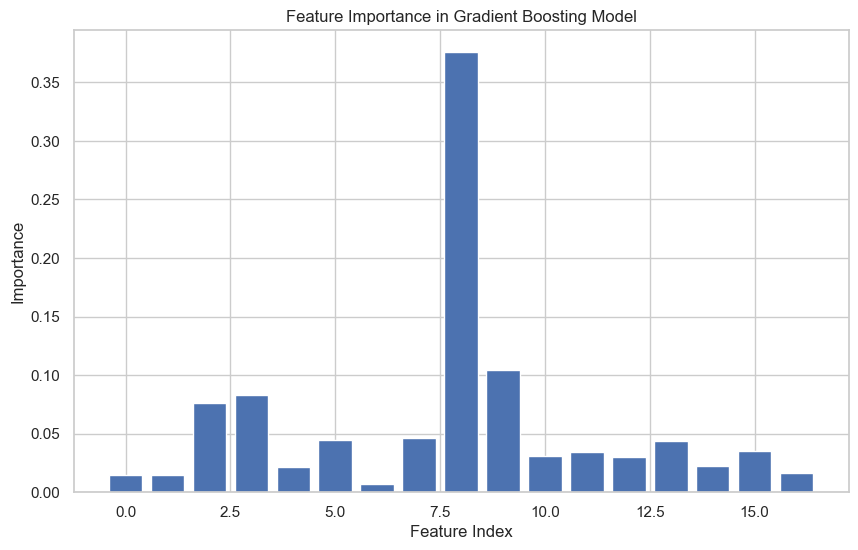

In [24]:
# Train Gradient Boosting Classifier
gboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gboost.fit(X_train, y_train)

# Predictions
y_pred_gboost = gboost.predict(X_test)

# Model Evaluation
accuracy_gboost = accuracy_score(y_test, y_pred_gboost)

print(f'Gradient Boosting Model Performance:')
print(f'Accuracy: {accuracy_gboost}')
classification_report_gboost = classification_report(y_test, y_pred_gboost)
print("\nClassification Report:\n", classification_report_gboost)

# Feature Importance
feature_importances = gboost.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance in Gradient Boosting Model')
plt.show()

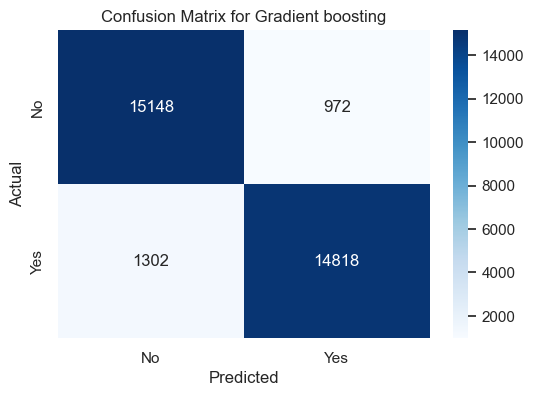

In [25]:
conf_matrix_gboost = confusion_matrix(y_test, y_pred_gboost)

# ✅ Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_gboost, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Gradient boosting")
plt.show()

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the parameter grid
param_dist = {
    "n_estimators": np.arange(50, 500, step=50),
    "learning_rate": [0.001, 0.01, 0.1, 0.2, 0.3],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6]
}

# Initialize the model
gboost = GradientBoostingClassifier(random_state=42)

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gboost, 
    param_distributions=param_dist, 
    n_iter=20,  # Reduce iterations for faster execution
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=2,
    random_state=42
)

# Fit the model
random_search.fit(X_train, y_train)

# Best hyperparameters
print("\n✅ Best Parameters (Randomized Search):", random_search.best_params_)

# Train final model with best params
best_gboost_random = GradientBoostingClassifier(**random_search.best_params_, random_state=42)
best_gboost_random.fit(X_train, y_train)

# Evaluate performance
y_pred_gboost = best_gboost_random.predict(X_test)
accuracy_gboost = accuracy_score(y_test, y_pred_gboost)
print(f"\n✅ **Final Gradient Boosting Model Accuracy (Randomized Search):** {accuracy_gboost:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Best Parameters (Randomized Search): {'subsample': 1.0, 'n_estimators': np.int64(300), 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 9, 'learning_rate': 0.3}

✅ **Final Gradient Boosting Model Accuracy (Randomized Search):** 0.9560



✅ **Final Gradient Boosting Model Accuracy (Randomized Search):** 0.9560

📊 **Final Model Performance (Tuned Gradient Boosting):**
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     16120
           1       0.96      0.95      0.96     16120

    accuracy                           0.96     32240
   macro avg       0.96      0.96      0.96     32240
weighted avg       0.96      0.96      0.96     32240



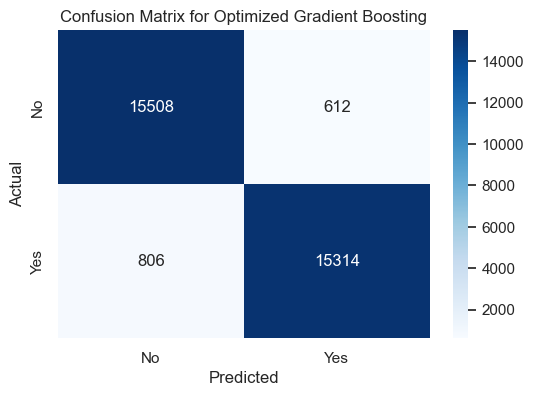

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

# Compare best model from Grid Search
print(f"\n✅ **Final Gradient Boosting Model Accuracy (Randomized Search):** {accuracy_gboost:.4f}")
print("\n📊 **Final Model Performance (Tuned Gradient Boosting):**")
print(classification_report(y_test, y_pred_gboost))

# Confusion Matrix
conf_matrix_gboost = confusion_matrix(y_test, y_pred_gboost)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_gboost, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Optimized Gradient Boosting")
plt.show()


## Deployement

In [29]:
import joblib
joblib.dump(best_gboost_random, "gradient_boosting_model.pkl")
print("✅ Model saved successfully!")

✅ Model saved successfully!
